In [57]:
import pandas as pd
import numpy as np
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df_initial = pd.read_excel("Online Retail.xlsx")
df = df_initial.copy()
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst rows:\n{df.head()}")

Shape: (541909, 8)

Column types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

First rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [4]:
print('Number of rows: ', df.shape[0])
print('Number of columns: ', df.shape[1])
print('Memory Usage: ', df.memory_usage().sum(), 'bytes')

Number of rows:  541909
Number of columns:  8
Memory Usage:  34682308 bytes


In [5]:
df.sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
384350,570116,22694,WICKER STAR,3,2011-10-07 12:38:00,2.10,12856.0,United Kingdom
391042,570650,21811,HANGING HEART WITH BELL,15,2011-10-11 13:13:00,0.39,13263.0,United Kingdom
469971,576615,22578,WOODEN STAR CHRISTMAS SCANDINAVIAN,3,2011-11-15 16:42:00,0.29,17231.0,United Kingdom
112567,545897,22199,FRYING PAN RED RETROSPOT,1,2011-03-07 17:22:00,8.29,NaN,United Kingdom
97675,544651,47580,TEA TIME DES TEA COSY,50,2011-02-22 12:51:00,2.10,13694.0,United Kingdom
91728,544115,22522,CHILDS GARDEN FORK BLUE,12,2011-02-16 11:45:00,0.85,12727.0,France
432674,573884,22687,had been put aside,20,2011-11-01 13:25:00,0.00,NaN,United Kingdom
14050,537446,82486,WOOD S/3 CABINET ANT WHITE FINISH,6,2010-12-07 09:13:00,7.95,18055.0,United Kingdom
463987,576076,22386,JUMBO BAG PINK POLKADOT,1,2011-11-13 16:18:00,2.08,14382.0,United Kingdom
251791,559055,11001,ASSTD DESIGN RACING CAR PEN,6,2011-07-05 17:09:00,0.83,NaN,United Kingdom


In [6]:
print('Missing values:')
print(df.isnull().sum())

print('\nMissing value percentages for each column:')
print((df.isnull().sum() * 100/ df.shape[0]).round(2))

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing value percentages for each column:
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


In [7]:
print('Number of unique values:')
print(df.nunique())

Number of unique values:
InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [9]:
print('Basic statistics:\n')
print(df.describe())

Basic statistics:

            Quantity                 InvoiceDate      UnitPrice     CustomerID
count  541909.000000                      541909  541909.000000  406829.000000
mean        9.552250  2011-07-04 13:34:57.156386       4.611114   15287.690570
min    -80995.000000         2010-12-01 08:26:00  -11062.060000   12346.000000
25%         1.000000         2011-03-28 11:34:00       1.250000   13953.000000
50%         3.000000         2011-07-19 17:17:00       2.080000   15152.000000
75%        10.000000         2011-10-19 11:27:00       4.130000   16791.000000
max     80995.000000         2011-12-09 12:50:00   38970.000000   18287.000000
std       218.081158                         NaN      96.759853    1713.600303


In [10]:
missing = df[df['CustomerID'].isna()]
valid = df[df['CustomerID'].notna()]

In [11]:
import pandas as pd
from collections import Counter

missing_counts = Counter(df[df['CustomerID'].isna()]['Country'])
missing_countries = list(missing_counts.keys())

total_counts = Counter(df['Country'][df['Country'].isin(missing_countries)])

valid_counts = {country: total_counts[country] - missing_counts[country] for country in missing_countries}

valid_prop = {country: valid_counts[country] / len(df) for country in missing_countries}

df_combined = pd.DataFrame({
    'Missing_Count': pd.Series(missing_counts),
    'Total_Count': pd.Series(total_counts),
    'Missing_Percentage': pd.Series({c: missing_counts[c]/total_counts[c]*100 for c in missing_countries}),
    'Valid_Proportion': pd.Series(valid_prop)
})

df_combined = df_combined.sort_values(by='Missing_Count', ascending=False)

print(df_combined)

                Missing_Count  Total_Count  Missing_Percentage  \
United Kingdom         133600       495478           26.963861   
EIRE                      711         8196            8.674963   
Hong Kong                 288          288          100.000000   
Unspecified               202          446           45.291480   
Switzerland               125         2002            6.243756   
France                     66         8557            0.771298   
Israel                     47          297           15.824916   
Portugal                   39         1519            2.567479   
Bahrain                     2           19           10.526316   

                Valid_Proportion  
United Kingdom          0.667784  
EIRE                    0.013812  
Hong Kong               0.000000  
Unspecified             0.000450  
Switzerland             0.003464  
France                  0.015669  
Israel                  0.000461  
Portugal                0.002731  
Bahrain                 

In [12]:
for col in ['Quantity', 'UnitPrice']:
    print(f"\n{col} stats:")
    print("Missing CustomerID:\n", missing[col].describe())
    print("Valid CustomerID:\n", valid[col].describe())


Quantity stats:
Missing CustomerID:
 count    135080.000000
mean          1.995573
std          66.696153
min       -9600.000000
25%           1.000000
50%           1.000000
75%           3.000000
max        5568.000000
Name: Quantity, dtype: float64
Valid CustomerID:
 count    406829.000000
mean         12.061303
std         248.693370
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

UnitPrice stats:
Missing CustomerID:
 count    135080.000000
mean          8.076577
std         151.900816
min      -11062.060000
25%           1.630000
50%           3.290000
75%           5.450000
max       17836.460000
Name: UnitPrice, dtype: float64
Valid CustomerID:
 count    406829.000000
mean          3.460471
std          69.315162
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max       38970.000000
Name: UnitPrice, dtype: float64


In [13]:
df['CustomerID_missing'] = df['CustomerID'].isna()

<pre>
CustomerID missingness depends on observed variables (Country),
which indicates the data is mostly MAR (Missing At Random).

However, since transaction values differ between groups,
some hidden MNAR effects may also exist.
</pre>

<pre>
Strategy: Indicator column.

CustomerID is missing in ~27% of the dataset, so deleting rows would remove too much information.

Instead, a new column CustomerID_missing is created to flag missing values.
</pre>

In [14]:
missing_desc_counts = Counter(df[df['Description'].isna()]['Country'])
missing_countries_desc = list(missing_desc_counts.keys())

In [15]:
total_counts_desc = Counter(df['Country'][df['Country'].isin(missing_countries_desc)])

valid_counts_desc = {country: total_counts_desc[country] - missing_desc_counts[country] for country in missing_countries_desc}

valid_prop_desc = {country: valid_counts_desc[country] / len(df) for country in missing_countries_desc}

df_missing_desc_combined = pd.DataFrame({
    'Missing_Count': pd.Series(missing_desc_counts),
    'Total_Count': pd.Series(total_counts_desc),
    'Missing_Percentage': pd.Series({c: missing_desc_counts[c]/total_counts_desc[c]*100 for c in missing_countries_desc}),
    'Valid_Proportion': pd.Series(valid_prop_desc)
})

df_missing_desc_combined = df_missing_desc_combined.sort_values(by='Missing_Count', ascending=False)

print(df_missing_desc_combined)

                Missing_Count  Total_Count  Missing_Percentage  \
United Kingdom           1454       495478            0.293454   

                Valid_Proportion  
United Kingdom          0.911636  


In [16]:
missing_desc_stock = df[df['Description'].isna()]['StockCode']

valid_stock_count = missing_desc_stock.notna().sum()
total_missing_desc = len(missing_desc_stock)

print(f"Rows with missing Description: {total_missing_desc}")
print(f"Rows with valid StockCode among them: {valid_stock_count}")

Rows with missing Description: 1454
Rows with valid StockCode among them: 1454


<pre>
Description is mostly MCAR if the missing rows have no pattern, because 0.3% is tiny and probably random.
For strategy: Deletion
the percentage is too low(only 0.3%) so it wouldnt affect the data too much.
</pre>

Dataset contains 541,909 rows and 8 columns with a total memory usage of about 33MB.

Missing values appear in two columns:
- CustomerID: 135,080 missing (~24.9%)
- Description: 1,454 missing (~0.27%)

All other columns contain complete data.

Numeric statistics show that Quantity ranges from -80,995 to 80,995 and UnitPrice ranges from -11,062 to 38,970, indicating the presence of returns and potential outliers.

In [17]:
"""

df['CustomerID_missing'] = df['CustomerID'].isna()

df['CustomerID'] = df['CustomerID'].fillna('Unknown')

df = df.dropna(subset=['Description'])

stock_to_desc = df.dropna(
    subset=['Description']).drop_duplicates('StockCode').set_index('StockCode')['Description']

df['Description'] = df.apply(
    lambda row: stock_to_desc[row['StockCode']] 
    if pd.isna(row['Description']) 
    else row['Description'], axis=1)


print(df.isnull().sum())

"""

"\n\ndf['CustomerID_missing'] = df['CustomerID'].isna()\n\ndf['CustomerID'] = df['CustomerID'].fillna('Unknown')\n\ndf = df.dropna(subset=['Description'])\n\nstock_to_desc = df.dropna(\n    subset=['Description']).drop_duplicates('StockCode').set_index('StockCode')['Description']\n\ndf['Description'] = df.apply(\n    lambda row: stock_to_desc[row['StockCode']] \n    if pd.isna(row['Description']) \n    else row['Description'], axis=1)\n\n\nprint(df.isnull().sum())\n\n"

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   InvoiceNo           541909 non-null  object        
 1   StockCode           541909 non-null  object        
 2   Description         540455 non-null  object        
 3   Quantity            541909 non-null  int64         
 4   InvoiceDate         541909 non-null  datetime64[us]
 5   UnitPrice           541909 non-null  float64       
 6   CustomerID          406829 non-null  float64       
 7   Country             541909 non-null  str           
 8   CustomerID_missing  541909 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.6+ MB


In [19]:
df[df['Quantity'] < 0].shape[0]

10624

In [20]:
# Filter invoices starting with 'C', safely ignoring NaN
c_invoices = df[df['InvoiceNo'].str.startswith('C', na=False)]

# Just see the InvoiceNo values
print(c_invoices['InvoiceNo'].shape[0])

9288


<pre>
Cancellations represent returned transactions rather than purchases.
Instead of deleting them, they were flagged so that return behavior can still be analyzed.
</pre>

In [21]:
df['Refund'] = np.where(df['InvoiceNo'].str.startswith('C', na=False), True,False)
df['Quantity'] = np.where(df['InvoiceNo'].str.startswith('C', na=False), np.abs(df['Quantity']), df['Quantity'])
neg_quantity_backup = df[~((df['Quantity'] < 0) & (df['Refund'] == 0))]
df = df[~((df['Quantity'] < 0) & (df['Refund'] == 0))]
(df['Quantity'] < 0).sum()


np.int64(0)

<pre>
Where Invoice starts with C, I turned Quantity positive and added new column named Refund (1 if it's cancellation, 0 if not). And as it seems there still exist 1336 null values(10624-9288)
</pre>

In [22]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Quantity_Outlier'] = (df['Quantity'] < lower) | (df['Quantity'] > upper)

print(df['Quantity_Outlier'].value_counts())

Quantity_Outlier
False    483089
True      57484
Name: count, dtype: int64


<pre>
Instead of removing outliers, they were flagged because extreme quantities
may represent legitimate bulk purchases.
</pre>

In [23]:
df[df['UnitPrice'] < 0].shape[0]

2

In [24]:
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerID_missing,Refund,Quantity_Outlier
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,True,False,False
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,True,False,False


In [25]:
df.loc[df['UnitPrice'] < 0, 'UnitPrice'] = df.loc[df['UnitPrice'] < 0, 'UnitPrice'].abs()
(df['UnitPrice'] < 0).sum()

np.int64(0)

<pre>
Since the number of affected rows is extremely small, the values were corrected
by converting them to absolute values.
</pre>

In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 540573 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   InvoiceNo           540573 non-null  object        
 1   StockCode           540573 non-null  object        
 2   Description         539981 non-null  object        
 3   Quantity            540573 non-null  int64         
 4   InvoiceDate         540573 non-null  datetime64[us]
 5   UnitPrice           540573 non-null  float64       
 6   CustomerID          406829 non-null  float64       
 7   Country             540573 non-null  str           
 8   CustomerID_missing  540573 non-null  bool          
 9   Refund              540573 non-null  bool          
 10  Quantity_Outlier    540573 non-null  bool          
dtypes: bool(3), datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 38.7+ MB


In [27]:
print("Initial shape:", df_initial.shape)
print("Final shape: ", df.shape)
print("Missing values per column:\n", df.isnull().sum())
print("Negative quantities:", (df['Quantity'] < 0).sum())
print("Negative unit prices:", (df['UnitPrice'] < 0).sum())

Initial shape: (541909, 8)
Final shape:  (540573, 11)
Missing values per column:
 InvoiceNo                  0
StockCode                  0
Description              592
Quantity                   0
InvoiceDate                0
UnitPrice                  0
CustomerID            133744
Country                    0
CustomerID_missing         0
Refund                     0
Quantity_Outlier           0
dtype: int64
Negative quantities: 0
Negative unit prices: 0


In [28]:
df.info()

<class 'pandas.DataFrame'>
Index: 540573 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   InvoiceNo           540573 non-null  object        
 1   StockCode           540573 non-null  object        
 2   Description         539981 non-null  object        
 3   Quantity            540573 non-null  int64         
 4   InvoiceDate         540573 non-null  datetime64[us]
 5   UnitPrice           540573 non-null  float64       
 6   CustomerID          406829 non-null  float64       
 7   Country             540573 non-null  str           
 8   CustomerID_missing  540573 non-null  bool          
 9   Refund              540573 non-null  bool          
 10  Quantity_Outlier    540573 non-null  bool          
dtypes: bool(3), datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 38.7+ MB


In [29]:
df['Country'].nunique()

38

In [30]:
"""df['Transaction'] = (df['Quantity'] * df['UnitPrice']).abs()
df.info()"""

"df['Transaction'] = (df['Quantity'] * df['UnitPrice']).abs()\ndf.info()"

In [31]:
"""transaction = df.groupby('Country')['Transaction'].sum().sort_values(ascending=False)"""

"transaction = df.groupby('Country')['Transaction'].sum().sort_values(ascending=False)"

In [32]:
country_counts = Counter(df['Country'])
countries = list(country_counts.keys())

total_transactions = len(df)

country_percentage = {c: country_counts[c] / total_transactions * 100 for c in countries}

df_country_summary = pd.DataFrame({
    'Transactions': pd.Series(country_counts),
    'Percentage_of_Total': pd.Series(country_percentage)
})

df_country_summary = df_country_summary.sort_values(by='Transactions', ascending=False)

print(df_country_summary)

                      Transactions  Percentage_of_Total
United Kingdom              494142            91.410781
Germany                       9495             1.756470
France                        8557             1.582950
EIRE                          8196             1.516169
Spain                         2533             0.468577
Netherlands                   2371             0.438609
Belgium                       2069             0.382742
Switzerland                   2002             0.370348
Portugal                      1519             0.280998
Australia                     1259             0.232901
Norway                        1086             0.200898
Italy                          803             0.148546
Channel Islands                758             0.140222
Finland                        695             0.128567
Cyprus                         622             0.115063
Sweden                         462             0.085465
Unspecified                    446             0

In [33]:
print('Percentage of transactions come from the top 5 countries: ',df_country_summary['Percentage_of_Total'].head(5).sum())

Percentage of transactions come from the top 5 countries:  96.7349460664887


In [34]:
print('Number of  countries that have fewer than 50 transactions: ', (df_country_summary['Transactions'] < 50).sum())

Number of  countries that have fewer than 50 transactions:  6


In [35]:
import pandas as pd
from collections import Counter

country_counts = Counter(df['Country'])

country_series = pd.Series(country_counts)

rare_countries = country_series[country_series < 50].index.tolist()

df['Country_Cleaned'] = df['Country'].apply(lambda x: 'Other' if x in rare_countries else x)

num_before = df['Country'].nunique()
num_after = df['Country_Cleaned'].nunique()

print(f"Number of unique countries before cleaning: {num_before}")
print(f"Number of unique countries after cleaning: {num_after}")

df['Country_Cleaned'].value_counts().tail(10)

Number of unique countries before cleaning: 38
Number of unique countries after cleaning: 33


Country_Cleaned
Hong Kong               288
Singapore               229
Iceland                 182
Other                   171
Canada                  151
Greece                  146
Malta                   127
United Arab Emirates     68
European Community       61
RSA                      58
Name: count, dtype: int64

In [36]:
df['StockCode'].nunique()

3957

In [37]:
stockcode_str = df['StockCode'].astype(str)

non_numeric_codes = stockcode_str[~stockcode_str.str.isnumeric()].unique()

import re
starting_with_letter = [code for code in non_numeric_codes if re.match(r'^[A-Za-z]', code)]

ending_with_letter = [code for code in non_numeric_codes if re.match(r'.*[A-Za-z]$', code)]

print("Non-numeric codes starting with a letter:")
print(starting_with_letter)

print("\nNon-numeric codes ending with a letter:")
print(ending_with_letter)

Non-numeric codes starting with a letter:
['POST', 'D', 'C2', 'DOT', 'M', 'BANK CHARGES', 'S', 'AMAZONFEE', 'DCGS0076', 'DCGS0003', 'gift_0001_40', 'DCGS0070', 'm', 'gift_0001_50', 'gift_0001_30', 'gift_0001_20', 'DCGS0069', 'DCGSSBOY', 'DCGSSGIRL', 'gift_0001_10', 'PADS', 'DCGS0004', 'B', 'CRUK']

Non-numeric codes ending with a letter:
['85123A', '84406B', '84029G', '84029E', 'POST', '82494L', '85099C', '84997B', '84997C', '84519A', '85183B', '85071B', '37444A', '37444C', '84971S', '15056BL', '15056N', 'D', '35004C', '85049A', '85099B', '35004G', '85014B', '85014A', '84970S', '84030E', '35004B', '85049E', '17091A', '84509A', '84510A', '84709B', '84625C', '84625A', '47570B', '85049C', '85049D', '85049G', '84970L', '90199C', '90129F', '90210B', '72802C', '85169B', '85099F', '85184C', '35591T', '84032B', '85049H', '72800E', '84849B', '90200B', '90059B', '90185C', '90059E', '90059C', '90200C', '90200D', '90200A', '16258A', '85231B', '85231G', '48173C', '47563A', '84558A', '46000M', '7140

<pre>
Keep codes that represent actual items sold, even if alphanumeric (DCGS*, gift*).
Remove codes representing postage, fees, or adjustments (POST, BANK CHARGES, AMAZONFEE, PADS).
</pre>

In [38]:
df['StockCode'].sample(10)

240625     21989
519311     23291
452567     21928
323893     22423
382677    35471D
330189     21530
185405     22487
95399      22624
416915     22382
240487    15044A
Name: StockCode, dtype: object

In [39]:
df_products = df[stockcode_str.str.isnumeric() | stockcode_str.str.match(r'\d+[A-Za-z]$')]

df['NonProduct'] = stockcode_str.str.match(r'^[A-Za-z]') & ~stockcode_str.str.match(r'\d+[A-Za-z]$')

print("Non-product rows:", df['NonProduct'].sum())

Non-product rows: 2983


In [40]:
import re

exclude_codes = ['POST', 'BANK CHARGES', 'AMAZONFEE', 'PADS', 'DOT']

def is_product_sku(code):
    if pd.isna(code):
        return False
    code = str(code).strip()
    
    # Exclude known non-product codes
    if code.upper() in exclude_codes:
        return False
    
    # 5-digit numeric SKUs
    if re.fullmatch(r'\d{5}', code):
        return True
    
    # 5-digit + 1 letter (6 chars) SKUs
    if re.fullmatch(r'\d{5}[A-Za-z]', code):
        return True
    
    # Gift or special SKUs starting with 'DCGS' or 'gift_'
    if code.startswith('DCGS') or code.startswith('gift_'):
        return True
    
    return False

# Apply filter
df['IsProduct'] = df['StockCode'].apply(is_product_sku)

# Count how many rows are non-product
print("Non-product rows:", (~df['IsProduct']).sum())
print("Product rows:", df['IsProduct'].sum())

# Keep only product rows if needed
df_products = df[df['IsProduct']].copy()

Non-product rows: 3304
Product rows: 537269


Flag IsProduct=True for valid SKUs

Exclude fees, postage, and other manual adjustments

Include gift/special SKUs and standard SKUs

Make df_products ready for product-level revenue analysis

In [41]:
# Flag products
df['IsProduct'] = ~df['StockCode'].isin(exclude_codes)
df['IsSKU'] = df['StockCode'].apply(is_product_sku)

# Filter to real products
df_products = df[df['IsProduct'] & df['IsSKU']].copy()  # <--- copy() avoids warnings

# Feature engineering from Description
df_products['Desc_Contains_SET'] = df_products['Description'].str.contains("SET", case=False)
df_products['Desc_Contains_PACK'] = df_products['Description'].str.contains("PACK", case=False)
df_products['Desc_Contains_VINTAGE'] = df_products['Description'].str.contains("VINTAGE", case=False)


df_products

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerID_missing,Refund,Quantity_Outlier,Country_Cleaned,NonProduct,IsProduct,IsSKU,Desc_Contains_SET,Desc_Contains_PACK,Desc_Contains_VINTAGE
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,False,False,United Kingdom,False,True,True,False,False,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,False,False,United Kingdom,False,True,True,False,False,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,False,False,United Kingdom,False,True,True,False,False,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,False,False,United Kingdom,False,True,True,False,False,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,False,False,United Kingdom,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,False,False,False,France,False,True,True,False,True,False
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,False,False,False,France,False,True,True,False,False,False
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,False,False,False,France,False,True,True,False,False,False
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,False,False,False,France,False,True,True,False,False,False


In [42]:
# Average Quantity and UnitPrice by keyword flags
keyword_features = ['Desc_Contains_SET', 'Desc_Contains_PACK', 'Desc_Contains_VINTAGE']

for feature in keyword_features:
    avg_stats = df_products.groupby(feature)[['Quantity', 'UnitPrice']].mean()
    print(f"\nAverage Quantity & UnitPrice by {feature}:\n", avg_stats)


Average Quantity & UnitPrice by Desc_Contains_SET:
                     Quantity  UnitPrice
Desc_Contains_SET                      
False              11.254813   3.250074
True                8.869971   3.487016

Average Quantity & UnitPrice by Desc_Contains_PACK:
                      Quantity  UnitPrice
Desc_Contains_PACK                      
False               10.763776   3.346597
True                17.393686   1.135480

Average Quantity & UnitPrice by Desc_Contains_VINTAGE:
                         Quantity  UnitPrice
Desc_Contains_VINTAGE                      
False                  11.002066   3.248385
True                   10.454791   3.728888


StockCode is high-cardinality — too many unique products for one-hot encoding.

Strategy: filter out non-product codes (POST, BANK CHARGES, etc.) and keep only real product SKUs.

Group rare countries into "Other" to reduce sparsity.

Engineered Feature:

Binary flags: Desc_Contains_SET, Desc_Contains_PACK, Desc_Contains_VINTAGE

Numeric feature: Desc_WordCount

Evidence of Usefulness:

Grouping by these flags shows clear differences in Quantity and UnitPrice.

High-Cardinality Strategy:

Keep only product SKUs (IsProduct=True)

Collapse rare categories (countries) → "Other"

In [43]:
df_valid = df_products.copy()

# Aggregate customer-level features
customer_df = df_valid.groupby('CustomerID').agg(
    total_revenue = ('Quantity', lambda q: (q * df_valid.loc[q.index, 'UnitPrice']).sum()),  # total revenue
    num_orders = ('InvoiceNo', 'nunique'),               # number of unique invoices
    num_products = ('StockCode', 'nunique'),            # number of distinct products purchased
    first_purchase = ('InvoiceDate', 'min'),            # date of first purchase
    last_purchase = ('InvoiceDate', 'max')              # date of last purchase
).reset_index()

# Compute the 90th percentile threshold for high-value customers
revenue_threshold = customer_df['total_revenue'].quantile(0.9)

# Create binary target: 1 if top 10% revenue, else 0
customer_df['high_value'] = (customer_df['total_revenue'] >= revenue_threshold).astype(int)

# Check results
print(customer_df.head())
print("\nHigh-value customer distribution:\n", customer_df['high_value'].value_counts())

   CustomerID  total_revenue  num_orders  num_products      first_purchase  \
0     12346.0      154367.20           2             1 2011-01-18 10:01:00   
1     12347.0        4310.00           7           103 2010-12-07 14:57:00   
2     12348.0        1437.24           4            21 2010-12-16 19:09:00   
3     12349.0        1457.55           1            72 2011-11-21 09:51:00   
4     12350.0         294.40           1            16 2011-02-02 16:01:00   

        last_purchase  high_value  
0 2011-01-18 10:17:00           1  
1 2011-12-07 15:52:00           1  
2 2011-09-25 13:13:00           0  
3 2011-11-21 09:51:00           0  
4 2011-02-02 16:01:00           0  

High-value customer distribution:
 high_value
0    3926
1     437
Name: count, dtype: int64


In [44]:
# Count of each class
class_counts = customer_df['high_value'].value_counts()
print("Class distribution:\n", class_counts)

# Proportion of each class
class_proportions = customer_df['high_value'].value_counts(normalize=True) * 100
print("\nClass proportions (%):\n", class_proportions)

# Accuracy if we always predict the majority class
majority_class = class_counts.idxmax()
majority_acc = class_counts.max() / class_counts.sum()
print(f"\nIf we always predict class {majority_class}, accuracy would be {majority_acc:.2%}")

Class distribution:
 high_value
0    3926
1     437
Name: count, dtype: int64

Class proportions (%):
 high_value
0    89.983956
1    10.016044
Name: proportion, dtype: float64

If we always predict class 0, accuracy would be 89.98%


Suppose 90% of customers are regular (0) and 10% are high-value (1).

If your model always predicts 0, it will be correct 90% of the time.

Class imbalance problem: Most customers are regular, so the model can “cheat” by predicting the majority class.

Ignoring the minority class: The high-value customers (the 10% you care about) are ignored.

Misleading performance: High accuracy doesn’t mean the model is useful — it can miss all valuable customers.

In [45]:
numeric_cols = ['total_revenue', 'num_orders', 'num_products']
X = customer_df[numeric_cols]
y = customer_df['high_value']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13, stratify=y)

In [47]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("High-value class distribution in train:\n", y_train.value_counts())
print("High-value class distribution in test:\n", y_test.value_counts())

Training set shape: (3490, 3)
Test set shape: (873, 3)
High-value class distribution in train:
 high_value
0    3140
1     350
Name: count, dtype: int64
High-value class distribution in test:
 high_value
0    786
1     87
Name: count, dtype: int64


In [48]:
print("Original training class distribution:", Counter(y_train))

Original training class distribution: Counter({0: 3140, 1: 350})


In [49]:
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)
print("After oversampling:", Counter(y_train_over))

After oversampling: Counter({0: 3140, 1: 3140})


In [50]:
lr_over = LogisticRegression(max_iter=1000, random_state=42)
lr_over.fit(X_train_over, y_train_over)
y_pred_over = lr_over.predict(X_test)
print("\nOversampled Logistic Regression Evaluation:\n", classification_report(y_test, y_pred_over, digits=4))



Oversampled Logistic Regression Evaluation:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       786
           1     1.0000    1.0000    1.0000        87

    accuracy                         1.0000       873
   macro avg     1.0000    1.0000    1.0000       873
weighted avg     1.0000    1.0000    1.0000       873



In [51]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
print("After undersampling:", Counter(y_train_under))


After undersampling: Counter({0: 350, 1: 350})


In [52]:
lr_under = LogisticRegression(max_iter=1000, random_state=42)
lr_under.fit(X_train_under, y_train_under)
y_pred_under = lr_under.predict(X_test)
print("\nUndersampled Logistic Regression Evaluation:\n", classification_report(y_test, y_pred_under, digits=4))



Undersampled Logistic Regression Evaluation:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       786
           1     1.0000    1.0000    1.0000        87

    accuracy                         1.0000       873
   macro avg     1.0000    1.0000    1.0000       873
weighted avg     1.0000    1.0000    1.0000       873



In [53]:
lr_orig = LogisticRegression(max_iter=1000, random_state=42)
lr_orig.fit(X_train, y_train)
y_pred_orig = lr_orig.predict(X_test)
print("\nOriginal Logistic Regression Evaluation:\n", classification_report(y_test, y_pred_orig, digits=4))


Original Logistic Regression Evaluation:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       786
           1     1.0000    1.0000    1.0000        87

    accuracy                         1.0000       873
   macro avg     1.0000    1.0000    1.0000       873
weighted avg     1.0000    1.0000    1.0000       873



In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Logistic Regression
lr_leak = LogisticRegression(max_iter=1000, random_state=42)
lr_leak.fit(X_train, y_train)

# Evaluate on test set
y_pred = lr_leak.predict(X_test)
print("Classification report (with temporal leakage):")
print(classification_report(y_test, y_pred, digits=4))

Classification report (with temporal leakage):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       786
           1     1.0000    1.0000    1.0000        87

    accuracy                         1.0000       873
   macro avg     1.0000    1.0000    1.0000       873
weighted avg     1.0000    1.0000    1.0000       873



Features summary (may include future info):
       total_revenue   num_orders  num_products   high_value
count    4363.000000  4363.000000   4363.000000  4363.000000
mean     2113.132893     4.993124     61.138895     0.100160
std     10270.257517     9.083794     85.318275     0.300248
min         0.000000     1.000000      1.000000     0.000000
25%       306.290000     1.000000     15.000000     0.000000
50%       671.630000     3.000000     35.000000     0.000000
75%      1656.055000     5.000000     77.000000     0.000000
max    336942.100000   242.000000   1790.000000     1.000000

Feature-target correlations:
high_value       1.000000
num_orders       0.544008
num_products     0.465539
total_revenue    0.361101
Name: high_value, dtype: float64


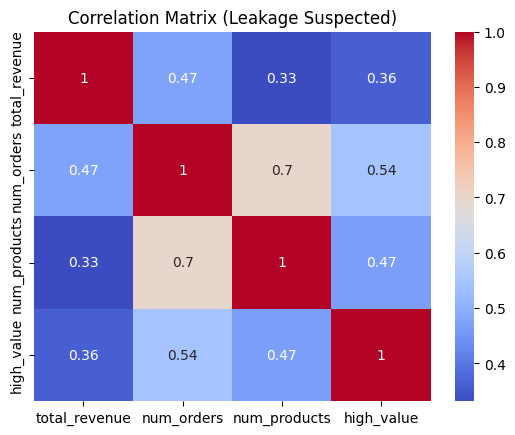

In [56]:

# 1. Check if features contain information from overlapping periods
# Example: total_revenue includes all purchases, even in Dec 2011
print("Features summary (may include future info):")
print(customer_df[numeric_cols + ['high_value']].describe())

# 2. Look at correlations between features and target
corr_matrix = customer_df[numeric_cols + ['high_value']].corr()
print("\nFeature-target correlations:")
print(corr_matrix['high_value'].sort_values(ascending=False))

# Plot correlations visually
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Leakage Suspected)")
plt.show()

In [ ]:
observation_end = pd.Timestamp("2011-09-30")
prediction_start = pd.Timestamp("2011-10-01")

df_obs = df_products[df_products["InvoiceDate"] <= observation_end]   # Observation window
df_pred = df_products[df_products["InvoiceDate"] >= prediction_start] # Prediction window


In [59]:
customer_features = df_obs.groupby('CustomerID').agg(
    total_revenue=('Quantity', lambda q: (q * df_obs.loc[q.index, 'UnitPrice']).sum()),
    num_orders=('InvoiceNo', 'nunique'),
    num_products=('StockCode', 'nunique'),
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max')
).reset_index()

In [60]:
high_value_customers = df_pred.groupby('CustomerID').size().reset_index(name='purchase_count')
high_value_customers['high_value'] = (high_value_customers['purchase_count'] > 0).astype(int)


In [61]:
customer_df_temp = customer_features.merge(high_value_customers[['CustomerID','high_value']],
                                           on='CustomerID', how='left')
customer_df_temp['high_value'] = customer_df_temp['high_value'].fillna(0).astype(int)


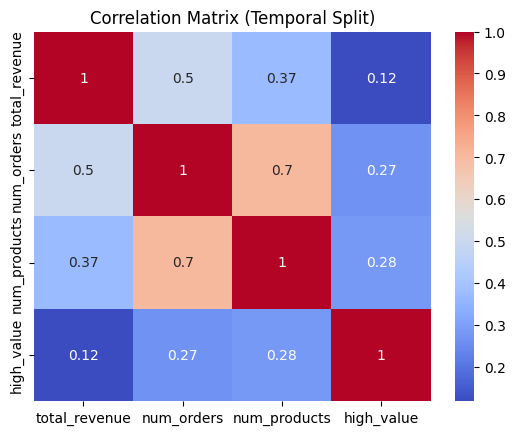

In [62]:
numeric_cols = ['total_revenue', 'num_orders', 'num_products']
corr_matrix = customer_df_temp[numeric_cols + ['high_value']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Temporal Split)")
plt.show()


In [63]:
print("\nFeature-target correlations:")
print(corr_matrix['high_value'].sort_values(ascending=False))



Feature-target correlations:
high_value       1.000000
num_products     0.279929
num_orders       0.266284
total_revenue    0.117921
Name: high_value, dtype: float64


In [64]:
X = customer_df_temp[numeric_cols]
y = customer_df_temp['high_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [65]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

              precision    recall  f1-score   support

           0       0.62      0.77      0.69       335
           1       0.76      0.60      0.67       393

    accuracy                           0.68       728
   macro avg       0.69      0.69      0.68       728
weighted avg       0.70      0.68      0.68       728



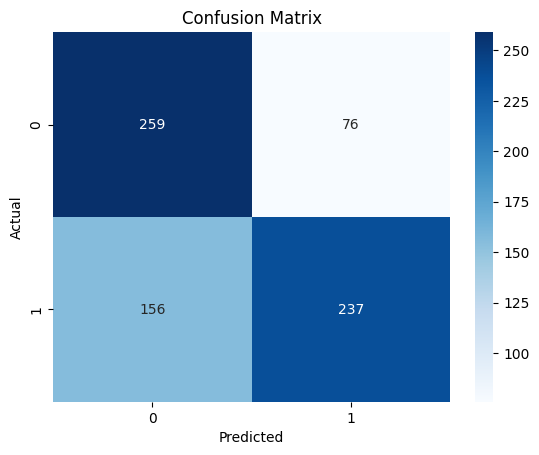

In [66]:
y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()